# 逻辑回归、Softmax回归和神经网络的对比

In [1]:
import torch
from torch import nn

In [2]:
class LogisticRegression(nn.Module):
    def __init__(self):
        super(LogisticRegression, self).__init__()
        self.linear = nn.Linear(in_features=2, 
                                out_features=1)

    def forward(self, x):
        x = self.linear(x)
        return torch.sigmoid(x)

In [3]:
class SoftmaxRegression(nn.Module):
    def __init__(self):
        super(SoftmaxRegression, self).__init__()
        self.linear = nn.Linear(in_features=2, 
                                out_features=2)

    def forward(self, x):
        x = self.linear(x)
        return nn.functional.log_softmax(x, dim=1)

In [4]:
class Network(nn.Module):
    def __init__(self):
        super(Network, self).__init__()
        self.hidden = nn.Linear(in_features=2, 
                                out_features=3)
        self.out = nn.Linear(in_features=3, 
                                out_features=2)

    def forward(self, x):
        x = self.hidden(x)
        x = torch.sigmoid(x)
        x = self.out(x)
        return nn.functional.log_softmax(x, dim=1)

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt 
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
import numpy as np

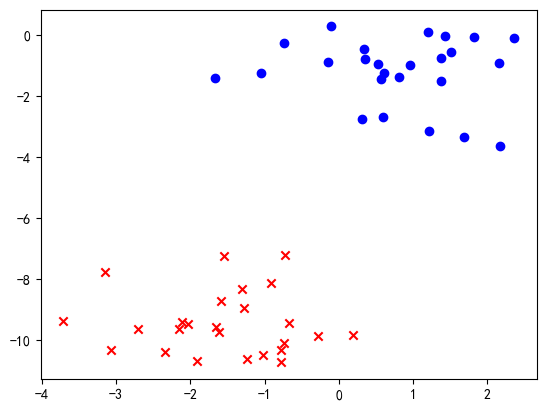

In [6]:
x, y = make_blobs(n_samples=50, centers=2, random_state=2, cluster_std=1)

x1 = x[:, 0]
x2 = x[:, 1]

plt.scatter(x1[y==1], x2[y==1], color='blue', marker='o')
plt.scatter(x1[y==0], x2[y==0], color='red', marker='x')

Epoch: 0, Loss: 2.629
Epoch: 1000, Loss: 0.239
Epoch: 2000, Loss: 0.110
Epoch: 3000, Loss: 0.056
Epoch: 4000, Loss: 0.032
Epoch: 5000, Loss: 0.019
Epoch: 6000, Loss: 0.012
Epoch: 7000, Loss: 0.008
Epoch: 8000, Loss: 0.005
Epoch: 9000, Loss: 0.003
Accuracy: 1.000


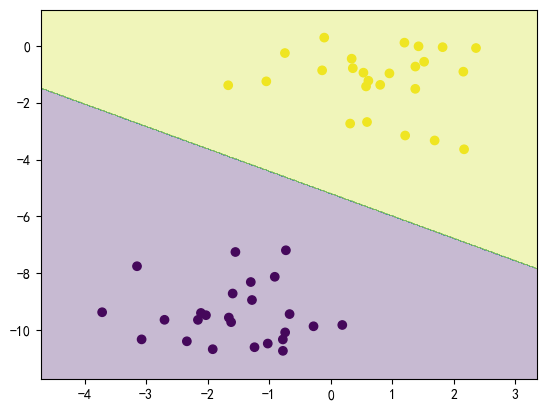

In [7]:
# softmax回归
x_tensor = torch.tensor(x, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long)

# 划分训练集和测试集（20% 作为测试集）
x_train, x_test, y_train, y_test = train_test_split(
    x_tensor, y_tensor, test_size=0.2, random_state=42
)

model = SoftmaxRegression()
optimizer = torch.optim.Adam(model.parameters())
criterion = nn.NLLLoss()

for epoch in range(10000):
    optimizer.zero_grad()
    y_pred = model(x_train)
    loss = criterion(y_pred, y_train)
    loss.backward()
    optimizer.step()

    if epoch % 1000 == 0:
        print(f'Epoch: {epoch}, Loss: {loss.item():.3f}')

# 在测试集上评估并可视化训练结果
with torch.no_grad():
    y_pred = model(x_test)
    y_pred = torch.argmax(y_pred, dim=1)    
    accuracy = ((y_pred == y_test).sum() / y_test.shape[0]).item()
    print(f'Accuracy: {accuracy:.3f}')


    # 可视化，并画出分界线
    plt.scatter(x1, x2, c=y, cmap='viridis')

    x1_min, x1_max = x1.min() - 1, x1.max() + 1
    x2_min, x2_max = x2.min() - 1, x2.max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, 0.02),
                           np.arange(x2_min, x2_max, 0.02))
    grid = np.c_[xx1.ravel(), xx2.ravel()]
    grid_tensor = torch.tensor(grid, dtype=torch.float32)
    y_pred = model(grid_tensor)
    y_pred = torch.argmax(y_pred, dim=1)
    y_pred = y_pred.reshape(xx1.shape)
    plt.contourf(xx1, xx2, y_pred, alpha=0.3)

    
    plt.show()
    


Epoch: 0, Loss: 0.725
Epoch: 1000, Loss: 0.185
Epoch: 2000, Loss: 0.058
Epoch: 3000, Loss: 0.024
Epoch: 4000, Loss: 0.012
Epoch: 5000, Loss: 0.006
Epoch: 6000, Loss: 0.004
Epoch: 7000, Loss: 0.002
Epoch: 8000, Loss: 0.001
Epoch: 9000, Loss: 0.001
Accuracy: 1.000


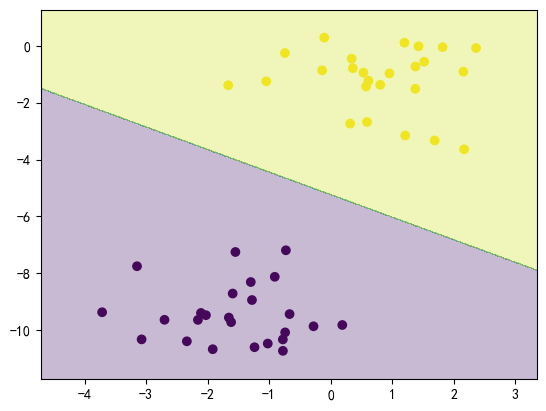

In [8]:
# 神经网络
x_tensor = torch.tensor(x, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long)

# 划分训练集和测试集（20% 作为测试集）
x_train, x_test, y_train, y_test = train_test_split(
    x_tensor, y_tensor, test_size=0.2, random_state=42
)

model = Network()
optimizer = torch.optim.Adam(model.parameters())
criterion = nn.NLLLoss()

for epoch in range(10000):
    optimizer.zero_grad()
    y_pred = model(x_train)
    loss = criterion(y_pred, y_train)
    loss.backward()
    optimizer.step()

    if epoch % 1000 == 0:
        print(f'Epoch: {epoch}, Loss: {loss.item():.3f}')

# 在测试集上评估并可视化训练结果
with torch.no_grad():
    y_pred = model(x_test)
    y_pred = torch.argmax(y_pred, dim=1)    
    accuracy = ((y_pred == y_test).sum() / y_test.shape[0]).item()
    print(f'Accuracy: {accuracy:.3f}')


    # 可视化，并画出分界线
    plt.scatter(x1, x2, c=y, cmap='viridis')

    x1_min, x1_max = x1.min() - 1, x1.max() + 1 
    x2_min, x2_max = x2.min() - 1, x2.max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, 0.02),
                           np.arange(x2_min, x2_max, 0.02))
    grid = np.c_[xx1.ravel(), xx2.ravel()]
    grid_tensor = torch.tensor(grid, dtype=torch.float32)
    y_pred = model(grid_tensor)
    y_pred = torch.argmax(y_pred, dim=1)
    y_pred = y_pred.reshape(xx1.shape)
    plt.contourf(xx1, xx2, y_pred, alpha=0.3)


    plt.show()

Epoch: 0, Loss: 0.687
Epoch: 1000, Loss: 0.305
Epoch: 2000, Loss: 0.188
Epoch: 3000, Loss: 0.126
Epoch: 4000, Loss: 0.085
Epoch: 5000, Loss: 0.058
Epoch: 6000, Loss: 0.040
Epoch: 7000, Loss: 0.028
Epoch: 8000, Loss: 0.019
Epoch: 9000, Loss: 0.014
Epoch: 10000, Loss: 0.010
Epoch: 11000, Loss: 0.007
Epoch: 12000, Loss: 0.005
Epoch: 13000, Loss: 0.004
Epoch: 14000, Loss: 0.003
Accuracy: 1.000


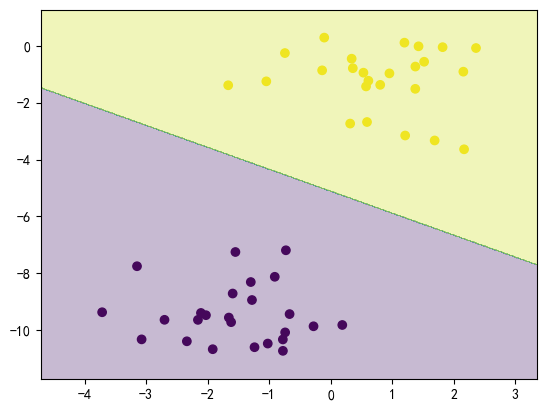

In [9]:
# 逻辑回归

x_tensor = torch.tensor(x, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).view(-1, 1)

# 划分训练集和测试集（20% 作为测试集）
x_train, x_test, y_train, y_test = train_test_split(
    x_tensor, y_tensor, test_size=0.2, random_state=42
)

model = LogisticRegression()
optimizer = torch.optim.Adam(model.parameters())
criterion = nn.BCELoss()

for epoch in range(15000):
    optimizer.zero_grad()
    y_pred = model(x_train)
    loss = criterion(y_pred, y_train)
    loss.backward()
    optimizer.step()

    if epoch % 1000 == 0:
        print(f'Epoch: {epoch}, Loss: {loss.item():.3f}')

# 在测试集上验证打印结果
with torch.no_grad():
    y_pred = model(x_test)
    y_pred = torch.round(y_pred)
    accuracy = ((y_pred == y_test).sum() / y_test.shape[0]).item()
    print(f'Accuracy: {accuracy:.3f}')
    # 可视化，并画出分界线
    plt.scatter(x1, x2, c=y, cmap='viridis')

    x1_min, x1_max = x1.min() - 1, x1.max() + 1
    x2_min, x2_max = x2.min() - 1, x2.max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, 0.02),
                           np.arange(x2_min, x2_max, 0.02))
    grid = np.c_[xx1.ravel(), xx2.ravel()]
    grid_tensor = torch.tensor(grid, dtype=torch.float32)
    y_pred = model(grid_tensor)
    y_pred = torch.round(y_pred)
    y_pred = y_pred.reshape(xx1.shape)
    plt.contourf(xx1, xx2, y_pred, alpha=0.3)
    plt.show()

